In [1]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
from modules_segmentation import *
from modules_prediction import *
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import cv2
import numpy as np

In [13]:
def enlarge_box(box, image_shape, scale=0.2):
    """
    Enlarge a bounding box by a given percentage.

    Parameters:
        box (tuple): (x1, y1, x2, y2)
        image_shape (tuple): (height, width, channels) of the image
        scale (float): Fraction to enlarge the box (e.g., 0.2 = 20%)

    Returns:
        tuple: New enlarged box (x1_new, y1_new, x2_new, y2_new)
    """
    x1, y1, x2, y2 = box
    width = x2 - x1
    height = y2 - y1

    # Amount to expand
    dx = int(width * scale / 2)
    dy = int(height * scale / 2)

    # New coordinates
    x1_new = max(x1 - dx, 0)
    y1_new = max(y1 - dy, 0)
    x2_new = min(x2 + dx, image_shape[1] - 1)
    y2_new = min(y2 + dy, image_shape[0] - 1)

    return (x1_new, y1_new, x2_new, y2_new)

In [40]:
#load image file
images_masked = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/03_images_masked"
file_list = os.listdir(images_masked)


#image_file = random.choice(file_list)#
image_file = "BRAIIM_0268.jpg"
print(image_file)
images_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped" 
labels_folder ="/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_labels_cropped"
image = cv2.imread(os.path.join(images_folder, image_file))
image_masked = cv2.imread(os.path.join(images_masked, image_file))

    
#recangles
if "TRIAVA" in image_file:
    min_area_contour = 100 
    max_area_contour = 2000
    scale = 1.5
    max_ratio = 2 
    upper_limit_rectangles = None
    value_threshold =97 # 5th percentile
    binary_default = False
elif "LIRIBO" in image_file: 
    min_area_contour = 1000 
    max_area_contour = 10000 
    scale = 1.5
    max_ratio = 1.76 #95th percentile
    upper_limit_rectangles = 28530 #22340 #95th percentile
    value_threshold = None
    binary_default = True
elif "BRAIIM" in image_file:
    min_area_contour = 2000 
    max_area_contour = 10000
    scale = 1.5
    max_ratio = 1.73 #1.75 #95the percentile
    upper_limit_rectangles = 42970 #41703 #95th percentil
    value_threshold = None
    binary_default = True

rectangles, v = get_list_of_rectangles(image_masked, min_area_contour, max_area_contour, scale, max_ratio, upper_limit_rectangles, value_threshold, binary_default)

if "TRIAVA" in image_file:
    rectangles = remove_smaller_overlaps(rectangles)

#convert xywh -> xyxy
rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in rectangles]

BRAIIM_0268.jpg
using only simple binarization.


In [36]:
print(len(rectangles))

32


In [41]:
rectangles[0]

(2474, 2180, 2589, 2295)

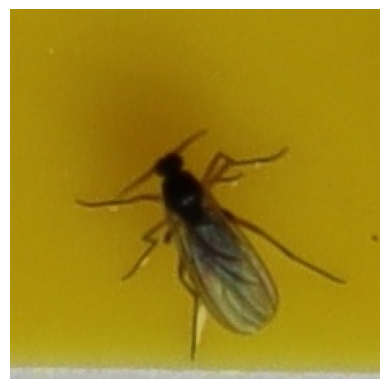

In [43]:
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
box = rectangles[0]
x1, y1, x2, y2 = map(int, box)
region_bgr = image[y1:y2, x1:x2]
region_hsv = hsv_image[y1:y2, x1:x2]
plt.imshow(cv2.cvtColor(region_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [42]:
scale = 1
rectangles = [enlarge_box(box, image.shape, scale) for box in rectangles]

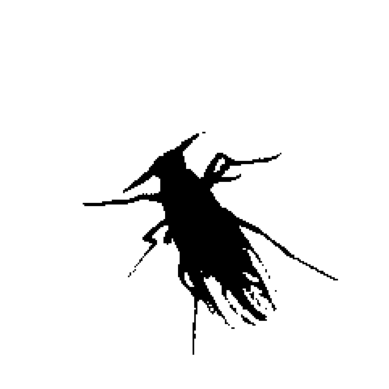

In [44]:
value = region_hsv[:, :, 2]

# --- Otsu threshold ---
otsu_thresh, binary_mask = cv2.threshold(value, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(binary_mask, cmap= "gray")
plt.axis("off")
plt.show()

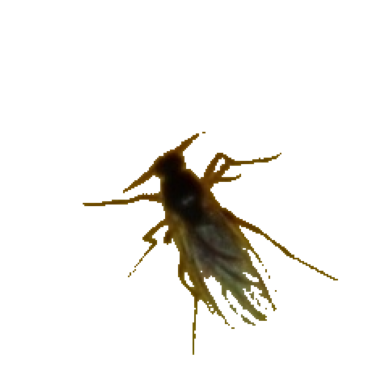

In [45]:
binary_mask_inv = cv2.bitwise_not(binary_mask)  # foreground=255, background=0

# Apply mask to the region_bgr
foreground = cv2.bitwise_and(region_bgr, region_bgr, mask=binary_mask_inv)

# Optional: set background to white
background = np.full_like(region_bgr, 255)  # white background
result = np.where(binary_mask_inv[:, :, np.newaxis] == 0, background, foreground)

# Show result
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()